<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sadistar/Business-Intelligence-et-analyse-de-donnees/blob/main/OpenClassrooms/Projet_06/notebook_bottleneck.ipynb)

# Téléchargement des fichiers sources depuis GitHub


In [298]:
import pandas as pd
import numpy as np

!wget https://github.com/Sadiestar/Business-Intelligence-et-analyse-de-donnees/raw/main/OpenClassrooms/Projet_06/web.xlsx
!wget https://github.com/Sadiestar/Business-Intelligence-et-analyse-de-donnees/raw/main/OpenClassrooms/Projet_06/erp.xlsx
!wget https://github.com/Sadiestar/Business-Intelligence-et-analyse-de-donnees/raw/main/OpenClassrooms/Projet_06/liaison.xlsx

--2026-09-23 06:59:44--  https://github.com/Sadiestar/Business-Intelligence-et-analyse-de-donnees/raw/main/OpenClassrooms/Projet_06/web.xlsx
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Sadiestar/Business-Intelligence-et-analyse-de-donnees/main/OpenClassrooms/Projet_06/web.xlsx [following]
--2026-09-23 06:59:44--  https://raw.githubusercontent.com/Sadiestar/Business-Intelligence-et-analyse-de-donnees/main/OpenClassrooms/Projet_06/web.xlsx
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 338853 (331K) [application/octet-stream]
Saving to: ‘web.xlsx.1’

web.xlsx.1          100%[===============

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [299]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np

In [300]:
#Importation de la librairie plotly express
import plotly.express as px

In [301]:
pd.set_option('display.max_columns', None)   # afficher toutes les colonnes
pd.set_option('display.width', 1000)         # élargir la largeur d'affichage
pd.set_option('display.max_colwidth', None)  # éviter la coupure du texte
pd.set_option('display.max_rows', None)      # afficher toutes les lignes

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [302]:
# Remplacez 'Projet_06_OpenClassrooms' par le nom exact de votre dossier sur Drive
chemin = './'
#Importation des sources à partir de Google Drive
df_web = pd.read_excel(chemin + "web.xlsx")
df_erp = pd.read_excel(chemin + "erp.xlsx")
df_liaison = pd.read_excel(chemin + "liaison.xlsx")
# L'avertissement indique que openpyxl n'arrive pas à lire certains éléments qui sont ignorés (sans incidences sur le projet)

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [303]:
# Methode shape
print(df_erp.shape)

# Afficher les dimensions du dataset
print("Le tableau comporte {} articles".format(df_erp.shape[0]))
print("Le tableau comporte {} colonnes".format(df_erp.shape[1]))

# Autre maniere avec f-strings
print(f"Dimensions : {df_erp.shape[0]} lignes × {df_erp.shape[1]} colonnes")

(825, 6)
Le tableau comporte 825 articles
Le tableau comporte 6 colonnes
Dimensions : 825 lignes × 6 colonnes


In [304]:
# Nature des données et valeurs présentes dans chacune des colonnes
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [305]:
# Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [306]:
# Vérifier si il y a des lignes en doublon dans la colonne product_id
nb_doublons = df_erp.duplicated('product_id').sum()
print(f"Doublons sur product_id : {nb_doublons}")

# Vérifier que chaque valeur de la colonne product_id est unique
df_erp['product_id'].nunique() == len(df_erp) # Si cette égalité est vraie alors chaque ligne correspond à un id unique => pas de duplication

Doublons sur product_id : 0


True

Les valeurs de la colonne "product_id" permettent d’identifier de façon unique chaque enregistrement de la table "erp". C'est donc une clé primaire.

In [307]:
#Afficher les valeurs distinctes de la colonne stock_status
print("Valeurs de stock_status :")
print(df_erp['stock_status'].value_counts()) # Analyse de la distribution des valeurs catégorielles de la colonne 'Stock_status'

Valeurs de stock_status :
stock_status
instock       733
outofstock     92
Name: count, dtype: int64


La colonne stock_status doit être en cohérence avec les valeurs de la colonne stock_quantity.

In [308]:
# Création d'une colonne stock_status_2 calculée à partir de stock_quantity : si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2'] = df_erp['stock_quantity'].apply(
    lambda x:
        'instock' if x > 0 else 'outofstock'
)
# Verification
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [309]:
# Comparaison des deux colonnes: on considere "stock_status_2" comme la source de vérité
nb_coherents = (df_erp['stock_status'] == df_erp['stock_status_2']).sum()
nb_incoherents = (df_erp['stock_status'] != df_erp['stock_status_2']).sum()

print(f"Lignes cohérentes   : {nb_coherents}")
print(f"Lignes incohérentes : {nb_incoherents}")

Lignes cohérentes   : 823
Lignes incohérentes : 2


🔴 ERREUR N°1 — Incohérence stock_status / stock_quantity

La colonne stock_status (instock / outofstock) doit refléter la colonne stock_quantity.

In [310]:
# Création d'un mask anomalies : si l'inégalité est vraie elle renvoie le booléen True (True=1)
mask = df_erp['stock_status'] != df_erp['stock_status_2']

# Affichage des lignes en écart
if nb_incoherents > 0:
    print("Lignes avec incohérence :")
    print(df_erp[mask][['product_id', 'stock_quantity', 'stock_status', 'stock_status_2']])

Lignes avec incohérence :
     product_id  stock_quantity stock_status stock_status_2
4          4039               3   outofstock        instock
398        4885               0      instock     outofstock


In [311]:
# Correction : on remplace les valeurs par celles données par la source de vérité (stock_status_2)
df_erp['stock_status'] = df_erp['stock_status_2']
df_erp.drop(columns=['stock_status_2'], inplace=True) # On supprime la colonne 'stock_status_2'

In [312]:
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [313]:
###############
## LES PRIX  ##
###############

# Afficher le ou les prix non renseignés dans la colonne "price"
print(f"Prix manquants  : {df_erp['price'].isna().sum()}") # isna détecte les valeurs manquantes (NaN), sum compte les 'True'
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp['price'].isna().sum())) # autre méthode

# Afficher le prix minimum de la colonne "price"
print(f"Prix minimum    : {df_erp['price'].min()}")

# Afficher le prix maximum de la colonne "price"
print(f"Prix maximum    : {df_erp['price'].max()}")

# Afficher les prix inférieurs à 0 => valeurs aberrantes
prix_negatifs = df_erp[df_erp['price'] < 0]
print(f"Articles avec prix négatif : {len(prix_negatifs)}")
print(prix_negatifs[['product_id', 'price', 'purchase_price', 'stock_quantity']])

# Afficher les prix nuls
prix_nuls = df_erp[df_erp['price'].isnull()]
print("Nombres d'articles avec un prix nul: {}".format(df_erp['price'].isnull().sum()))


Prix manquants  : 0
Nombres d'articles avec un prix non renseigné: 0
Prix minimum    : -20.0
Prix maximum    : 225.0
Articles avec prix négatif : 3
     product_id  price  purchase_price  stock_quantity
151        4233  -20.0           10.33               0
469        5017   -8.0            4.34               0
739        6594   -9.1            4.61              19
Nombres d'articles avec un prix nul: 0


🔴 ERREUR N°2 — Prix négatifs dans l'ERP

Des prix négatifs sont impossibles pour un article en vente. Il s'agit très probablement d'erreurs de saisie.

In [314]:
# Correction : on transforme les valeurs de 'price' en valeur absolue pour ne plus avoir de prix négatifs
df_erp['price'] = df_erp['price'].abs()
print("✅ Prix négatifs corrigés (valeur absolue appliquée)")
print(f"Nouveau prix minimum : {df_erp['price'].min()}")

✅ Prix négatifs corrigés (valeur absolue appliquée)
Nouveau prix minimum : 5.2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [315]:

#######################
### stock_quantity  ###
#######################

# Afficher la quantité minimum de la colonne "stock_quantity"
print(f"Stock minimum : {df_erp['stock_quantity'].min()}")

# Afficher la quantité maximum de la colonne "stock_quantity"
print(f"Stock maximum : {df_erp['stock_quantity'].max()}")

# Afficher les stocks inférieurs à 0
stock_negatif = df_erp[df_erp['stock_quantity'] < 0]
print(f"Articles avec stock négatif : {len(stock_negatif)}")
print(stock_negatif[['product_id', 'stock_quantity', 'stock_status', 'price']])

Stock minimum : -10
Stock maximum : 145
Articles avec stock négatif : 2
     product_id  stock_quantity stock_status  price
449        4973             -10   outofstock   10.0
573        5700              -1   outofstock   44.5


🔴 ERREUR N°3 — Quantités de stock négatives

Un stock ne peut pas être négatif. Ces valeurs correspondent probablement à des erreurs de saisie.

In [316]:
# Correction : ramener les stocks négatifs à 0 grace à la fonction clip
df_erp['stock_quantity'] = df_erp['stock_quantity'].clip(lower=0) #Si une valeur de stock est inférieure à 0, on la remplace par 0
print("✅ Stocks négatifs ramenés à 0")

✅ Stocks négatifs ramenés à 0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [317]:
# La colonne onsale_web designe les ventes réalisées sur le web "onsale_web == 1"
print(f"Il y a {(df_erp['onsale_web']==1).sum()} références produit vendues en ligne.")

Il y a 716 références produit vendues en ligne.


In [318]:
# Selection des ventes réalisées exclusivement sur le web
df_erp = df_erp[df_erp['onsale_web']==1].copy()
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 716 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      716 non-null    int64  
 1   onsale_web      716 non-null    int64  
 2   price           716 non-null    float64
 3   stock_quantity  716 non-null    int64  
 4   stock_status    716 non-null    object 
 5   purchase_price  716 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 39.2+ KB


Pour la suite de l'analyse on conserve le dataframe df_erp filtré sur les ventes en ligne.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [319]:
######################
##   prix d'achat   ##
######################

# Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print(f"Prix d'achat non renseignés  : {df_erp['purchase_price'].isna().sum()}") # isna détecte les valeurs manquantes (NaN), sum compte les True

# Afficher le prix maximum de la colonne "purchase_price"
print(f"Prix d'achat maximum : {df_erp['purchase_price'].max()}")

# Afficher le prix minimum de la colonne "purchase_price"
print(f"Prix d'achat minimum : {df_erp['purchase_price'].min()}")

Prix d'achat non renseignés  : 0
Prix d'achat maximum : 137.81
Prix d'achat minimum : 2.74


In [320]:
# Comparaison du prix d'achat et de vente
df_achat_vente = df_erp.copy()
df_achat_vente['marge'] = df_achat_vente['price']-df_achat_vente['purchase_price']
df_achat_vente.loc[df_achat_vente['marge']<0,:]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,marge
210,4355,1,12.65,97,instock,77.48,-64.83


🔴 ERREUR N°4 — Prix de vente inférieur au prix d'achat

Une marge négative identifiée sur un produit indique une incohérence entre le prix de vente et le prix d’achat. Cette anomalie est probablement liée à une erreur de saisie ou à un problème de mise à jour des données. Afin de garantir la fiabilité de l’analyse, cette observation est exclue du dataset.

In [321]:
# On exclut la valeur incohérente
df_achat_vente.loc[df_achat_vente['product_id'] == 4355, ['price', 'purchase_price']] = np.nan

In [322]:
# On enregistre les modifications dans le dataframe df_erp
df_erp = df_achat_vente.copy()

In [323]:
df_erp.loc[df_erp['product_id'] == 4355, :]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,marge
210,4355,1,NaN,97,instock,NaN,-64.83


In [324]:
df_erp.info()


<class 'pandas.core.frame.DataFrame'>
Index: 716 entries, 0 to 824
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      716 non-null    int64  
 1   onsale_web      716 non-null    int64  
 2   price           715 non-null    float64
 3   stock_quantity  716 non-null    int64  
 4   stock_status    716 non-null    object 
 5   purchase_price  715 non-null    float64
 6   marge           716 non-null    float64
dtypes: float64(3), int64(3), object(1)
memory usage: 44.8+ KB


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [325]:
# Dimension du dataset
print(df_web.shape)

# Nombre d'observations
print("Le tableau comporte {} observations\n".format(df_web.shape[0]))

# Nombre de caractéristiques
print("Le tableau comporte {} colonnes\n".format(df_web.shape[1]))

# Autre maniere avec f-strings
print(f"Dimensions : {df_web.shape[0]} lignes × {df_web.shape[1]} colonnes\n")

(1513, 29)
Le tableau comporte 1513 observations

Le tableau comporte 29 colonnes

Dimensions : 1513 lignes × 29 colonnes



In [326]:
# La nature des données dans chacune des colonnes et le nombre de valeurs présentes dans chacune des colonnes
resume = pd.DataFrame({
    "Type": df_web.dtypes,
    "Valeurs_non_nulles": df_web.count(),
    "Valeurs_manquantes": df_web.isnull().sum(),
    "Total_lignes": len(df_web)
})

print(resume)

                                 Type  Valeurs_non_nulles  Valeurs_manquantes  Total_lignes
sku                            object                1428                  85          1513
virtual                         int64                1513                   0          1513
downloadable                    int64                1513                   0          1513
rating_count                    int64                1513                   0          1513
average_rating                float64                1430                  83          1513
total_sales                   float64                1430                  83          1513
tax_status                     object                 716                 797          1513
tax_class                     float64                   0                1513          1513
post_author                   float64                1430                  83          1513
post_date              datetime64[ns]                1430                  83   

In [327]:
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [328]:
# Suppression des colonnes sans valeur métier
cols_to_drop = [
    "tax_class", "post_content", "post_password", "post_content_filtered","guid", "menu_order", "post_mime_type", "ping_status","post_date_gmt", "post_modified_gmt",
    "post_excerpt", "post_name", "virtual", "downloadable", "post_parent", "comment_status", "comment_count", "rating_count", "average_rating", "tax_status", "post_author", "post_status",
    "post_modified", "post_date"
]

df_web = df_web.drop(columns=cols_to_drop, errors="ignore")


In [329]:
df_web.head()

,sku,total_sales,product_type,post_title,post_type
0,11862,3.0,Vin,Gilles Robin Hermitage Rouge 2012,attachment
1,16057,5.0,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde 2017,attachment
2,14692,5.0,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,product
3,16295,14.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Rosé 2019,attachment
4,15328,2.0,Vin,Agnès Levet Côte Rôtie Maestria 2017,product


In [330]:
print("Vérification des SKU qui ne semblent pas respecter la régle de codification")

# SKU manquants
mask_null = df_web['sku'].isna()
nb_null = df_web['sku'].isna().sum()

# SKU en doublon
mask_dup = df_web['sku'].duplicated()
nb_dup = df_web['sku'].duplicated().sum()

# Regroupement des anomalies
mask_anomalies = mask_null | mask_dup

# Consultation des lignes problématiques
df_anomalies = df_web[mask_anomalies][:]
print(f"SKU manquants : {nb_null}")
print(f"SKU en doublon : {nb_dup}")
print(f"Total anomalies : {len(df_anomalies)}")

Vérification des SKU qui ne semblent pas respecter la régle de codification
SKU manquants : 85
SKU en doublon : 798
Total anomalies : 799


In [331]:
# Lignes sans code article
df_sans_sku = df_web[
    df_web["sku"].isnull() | (df_web["sku"].str.strip() == "") # sku manquants OU chaînes vides/remplies d’espaces
]
print(f"Il y a {len(df_sans_sku)} lignes sans code article sku.\n")
df_sans_sku.info()

Il y a 85 lignes sans code article sku.

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   2 non-null      float64
 2   product_type  2 non-null      object 
 3   post_title    2 non-null      object 
 4   post_type     2 non-null      object 
dtypes: float64(1), object(4)
memory usage: 4.0+ KB


🔴 ERREUR N°5 — Les lignes sans code article ne peuvent pas être exploitées.


In [332]:
# Visualisation des lignes non nulles dans le dataframe df_sans_sku
df_sans_sku[df_sans_sku["total_sales"].notnull()]

,sku,total_sales,product_type,post_title,post_type
1084,NaN,-56.0,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,product
1087,NaN,-17.0,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,product


🔴 ERREUR N°6 — Total des ventes (total_sales) négatif

Des ventes négatives n'ont pas de sens commercial. Cela n'a pas d'incidence car ces lignes font parties des lignes sans sku supprimées.


In [333]:
# Exclusion des lignes sans code article SKU
df_web_clean = df_web[
    ~(df_web["sku"].isnull() | (df_web["sku"].str.strip() == "")) # garder uniquement les lignes où le code article (sku) est valide
]

In [334]:
# On verifie bien passer de 1513 lignes à 1428 soit 85 de moins
df_web.info()
df_web_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           1428 non-null   object 
 1   total_sales   1430 non-null   float64
 2   product_type  1429 non-null   object 
 3   post_title    1430 non-null   object 
 4   post_type     1430 non-null   object 
dtypes: float64(1), object(4)
memory usage: 59.2+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 1428 entries, 0 to 1512
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           1428 non-null   object 
 1   total_sales   1428 non-null   float64
 2   product_type  1427 non-null   object 
 3   post_title    1428 non-null   object 
 4   post_type     1428 non-null   object 
dtypes: float64(1), object(4)
memory usage: 66.9+ KB


In [335]:
# Identification des doublons
df_doublons = df_web_clean[df_web_clean["sku"].duplicated(keep=False)]

In [336]:
# Visualisation des doublons
for i, (sku, group) in enumerate(df_doublons.groupby("sku")):
    if i == 5:
        break
    print(f"\n=== SKU : {sku} ===")
    display(group)


=== SKU : 38 ===


,sku,total_sales,product_type,post_title,post_type
458,38,10.0,Vin,Emile Boeckel Crémant Brut Blanc de Blancs,attachment
964,38,10.0,Vin,Emile Boeckel Crémant Brut Blanc de Blancs,product



=== SKU : 41 ===


,sku,total_sales,product_type,post_title,post_type
965,41,6.0,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurztraminer,product
1127,41,6.0,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurztraminer,attachment



=== SKU : 304 ===


,sku,total_sales,product_type,post_title,post_type
297,304,8.0,Champagne,Champagne Gosset Grande Réserve,attachment
1210,304,8.0,Champagne,Champagne Gosset Grande Réserve,product



=== SKU : 523 ===


,sku,total_sales,product_type,post_title,post_type
899,523,0.0,Cognac,Cognac Normandin Mercier VFC,product
1430,523,0.0,Cognac,Cognac Normandin Mercier VFC,attachment



=== SKU : 531 ===


,sku,total_sales,product_type,post_title,post_type
501,531,8.0,Champagne,Champagne Petit Lebrun &amp; Fils Blanc de Blancs Grand Cru,attachment
1442,531,8.0,Champagne,Champagne Petit Lebrun &amp; Fils Blanc de Blancs Grand Cru,product


In [337]:
# Identifier les différents types de la colonne "post_type"
print("Types de post_type :")
print(df_web_clean['post_type'].value_counts())

Types de post_type :
post_type
attachment    714
product       714
Name: count, dtype: int64


In [338]:
# On conserve uniquement les produits de la colonne "post_type"
df_web_products = df_web_clean[df_web_clean['post_type'] == 'product'].copy()
print(f"Produits en ligne : {len(df_web_products)}")

Produits en ligne : 714


In [339]:
df_web_products.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           714 non-null    object 
 1   total_sales   714 non-null    float64
 2   product_type  713 non-null    object 
 3   post_title    714 non-null    object 
 4   post_type     714 non-null    object 
dtypes: float64(1), object(4)
memory usage: 33.5+ KB


In [340]:
# Identifier les différents types de la colonne 'SKU' (car la fonction info indique un melange de type "objet")
df_web_products['sku'].apply(type).value_counts()

,count
sku,
<class 'int'>,712
<class 'str'>,2


In [341]:
# Identifier les valeurs suspects c-à-dire non 'int' (montrer les valeurs qui n’ont pas pu être converties en nombre) => isna()
df_sku_non_numeric = df_web_products[
    pd.to_numeric(df_web_products['sku'], errors='coerce').isna()
]
df_sku_non_numeric

,sku,total_sales,product_type,post_title,post_type
272,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,product
1387,bon-cadeau-25-euros,7.0,NaN,Bon cadeau de 25€,product


In [342]:
df_sku_numeric = df_web_products[
    pd.to_numeric(df_web_products['sku'], errors='coerce').notna()
].copy()

df_sku_numeric['sku'] = df_sku_numeric['sku'].astype(int) # Conversion en type int afin d'assurer la jointure avec 'id_web' (cf.df_liaison)

🔴 ERREUR N°7 — Les valeurs non numériques de la clé sku ont été identifiées via une conversion contrôlée (pd.to_numeric). Les valeurs invalides, transformées en NaN (errors='coerce'), ont été isolées avec isna() puis exclues du dataset avec notna() afin de garantir la fiabilité des jointures.

In [343]:
df_web_products = df_sku_numeric
df_web_products.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 2 to 1509
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           712 non-null    int64  
 1   total_sales   712 non-null    float64
 2   product_type  712 non-null    object 
 3   post_title    712 non-null    object 
 4   post_type     712 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 33.4+ KB


In [344]:
df_web_products.head()

,sku,total_sales,product_type,post_title,post_type
2,14692,5.0,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,product
4,15328,2.0,Vin,Agnès Levet Côte Rôtie Maestria 2017,product
6,16515,10.0,Vin,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,product
11,16585,15.0,Vin,Xavier Frissant Touraine Sauvignon 2019,product
14,12869,7.0,Vin,Stéphane Tissot Arbois D.D. 2016,product


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [345]:
#Dimension du dataset
print(df_liaison.shape)

#Nombre d'observations
print("Le tableau comporte {} observations\n".format(df_liaison.shape[0]))

#Nombre de caractéristiques
print("Le tableau comporte {} colonnes\n".format(df_liaison.shape[1]))

df_liaison.head()

(825, 2)
Le tableau comporte 825 observations

Le tableau comporte 2 colonnes



,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039


In [346]:
# La nature des données dans chacune des colonnes et le nombre de valeurs présentes dans chacune des colonnes
resume_liaison = pd.DataFrame({
    "Type": df_liaison.dtypes,
    "Valeurs_non_nulles": df_liaison.count(),
    "Valeurs_manquantes": df_liaison.isnull().sum(),
    "Total_lignes": len(df_liaison)
})

print(resume_liaison)

              Type  Valeurs_non_nulles  Valeurs_manquantes  Total_lignes
id_web      object                 734                  91           825
product_id   int64                 825                   0           825


In [347]:
# Vérifier que chaque valeur de la colonne "id_web" est unique
is_unique = df_liaison["id_web"].is_unique
print("id_web est unique ?", is_unique)


id_web est unique ? False


In [348]:
# Compter les doublons (hors NaN)
nb_doublons = df_liaison[
    df_liaison['id_web'].notna()
]['id_web'].duplicated().sum()

print(nb_doublons)

0


In [349]:
# Détail des différents type de la colonne id_web
df_liaison['id_web'].apply(type).value_counts()

,count
id_web,
<class 'int'>,731
<class 'float'>,91
<class 'str'>,3


🔴 ERREUR N°8 — Identification de 3 valeurs "id_web" non numérique

In [350]:
# Identification des valeurs "id_web" non numériques
df_liaison[df_liaison['id_web'].apply(lambda x: isinstance(x, str))]

,id_web,product_id
443,bon-cadeau-25-euros,4954
822,13127-1,7247
823,14680-1,7329


In [351]:
# Vérifier si il y a des lignes en doublon dans la colonne "product_id"
nb_doublons = df_liaison.duplicated('product_id').sum()
print(f"Doublons sur product_id : {nb_doublons}")

# Vérifier que chaque valeur de la colonne product_id est unique
df_liaison['product_id'].nunique() == len(df_liaison) # Si cette égalité est vraie alors chaque ligne correspond à un id unique => pas de duplication

Doublons sur product_id : 0


True

In [352]:
# Vérifier les articles ERP sans correspondance Web
df_sans_web = df_liaison[df_liaison["id_web"].isnull()]
print("Articles sans correspondance Web :", len(df_sans_web))
df_sans_web.head()

Articles sans correspondance Web : 91


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209


🔴 ERREUR N°9 — Produits ERP sans correspondance web (id_web manquant)

La table de liaison contient des product_id ERP sans id_web associé. Ces produits existent dans l'ERP mais ne sont pas publiés sur le site web.

In [353]:
# Vérifier les articles Web sans correspondance ERP
df_sans_erp = df_liaison[df_liaison["product_id"].isnull()]
print("Articles sans correspondance ERP :", len(df_sans_erp))
df_sans_erp.head()

Articles sans correspondance ERP : 0


,id_web,product_id


A contrario dans la table de liaison tous les articles WEB ont une correspondance dans ERP.

In [354]:
# Création d'une table de liaison fiable
df_liaison_clean = df_liaison.copy()

# Conversion sécurisée en numérique
df_liaison_clean['id_web'] = pd.to_numeric(df_liaison_clean['id_web'], errors='coerce')

# Garder uniquement les lignes valides
df_liaison_clean = df_liaison_clean[
    df_liaison_clean['id_web'].notna()
].copy()

# Conversion finale en entier
df_liaison_clean['product_id'] = df_liaison_clean['product_id'].astype(int)
df_liaison_clean['id_web'] = df_liaison_clean['id_web'].astype(int)

In [355]:
# Table de liaison propre
print(f"Lignes retenues dans la table de liaison : {len(df_liaison_clean)}")

Lignes retenues dans la table de liaison : 731


In [356]:
df_liaison_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 731 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_web      731 non-null    int64
 1   product_id  731 non-null    int64
dtypes: int64(2)
memory usage: 17.1 KB


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [357]:
# Fusion des fichiers df_erp et df_liaison
# On se base sur les 716 références produit de df_erp vendues sur le web (c-à-dire 'onsale_web' == 1)
df_merge = pd.merge(df_erp, df_liaison_clean, on ='product_id', how='left')
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716 entries, 0 to 715
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      716 non-null    int64  
 1   onsale_web      716 non-null    int64  
 2   price           715 non-null    float64
 3   stock_quantity  716 non-null    int64  
 4   stock_status    716 non-null    object 
 5   purchase_price  715 non-null    float64
 6   marge           716 non-null    float64
 7   id_web          711 non-null    float64
dtypes: float64(4), int64(3), object(1)
memory usage: 44.9+ KB


In [358]:
# Identifier les références produit présentent dans l'ERP mais qui ne sont pas mappées dans la table de liaison
df_sans_liaison = df_erp[
    ~df_erp["product_id"].isin(df_liaison_clean["product_id"])
]
df_sans_liaison

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,marge
242,4594,1,144.0,0,outofstock,87.36,56.64
443,4954,1,25.0,23,instock,13.30,11.70
486,5070,1,84.7,0,outofstock,47.43,37.27
487,5075,1,43.3,0,outofstock,21.70,21.60
822,7247,1,54.8,6,instock,27.18,27.62


🔴 ERREUR N°10 — Certaines références produit normalement vendues sur le web ne sont pas mappées dans la table de liaison.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [359]:
# Fusion des datasets df_merge et df_web_products
df_merge_web = pd.merge(df_merge, df_web_products, left_on='id_web', right_on='sku', how='left')
df_merge_web.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,marge,id_web,sku,total_sales,product_type,post_title,post_type
0,3847,1,24.2,16,instock,12.88,11.32,15298.0,15298.0,6.0,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,product
1,3849,1,34.3,10,instock,17.54,16.76,15296.0,15296.0,9.0,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,product
2,3850,1,20.8,0,outofstock,10.64,10.16,15300.0,15300.0,0.0,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Coeur 2018,product
3,4032,1,14.1,26,instock,6.92,7.18,19814.0,19814.0,12.0,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Gamine 2018,product
4,4039,1,46.0,3,instock,23.77,22.23,19815.0,19815.0,3.0,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,product


In [360]:
# Colonnes utiles pour l'analyse
colonnes_utiles = ['product_id','id_web','product_type', 'post_title',
                   'total_sales', 'price', 'purchase_price',
                   'stock_quantity', 'stock_status']
df_final = df_merge_web[colonnes_utiles].copy()
df_final.info()
df_final.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716 entries, 0 to 715
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      716 non-null    int64  
 1   id_web          711 non-null    float64
 2   product_type    711 non-null    object 
 3   post_title      711 non-null    object 
 4   total_sales     711 non-null    float64
 5   price           715 non-null    float64
 6   purchase_price  715 non-null    float64
 7   stock_quantity  716 non-null    int64  
 8   stock_status    716 non-null    object 
dtypes: float64(4), int64(2), object(3)
memory usage: 50.5+ KB


,product_id,id_web,product_type,post_title,total_sales,price,purchase_price,stock_quantity,stock_status
0,3847,15298.0,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,6.0,24.2,12.88,16,instock
1,3849,15296.0,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,9.0,34.3,17.54,10,instock
2,3850,15300.0,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Coeur 2018,0.0,20.8,10.64,0,outofstock
3,4032,19814.0,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Gamine 2018,12.0,14.1,6.92,26,instock
4,4039,19815.0,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,3.0,46.0,23.77,3,instock


In [361]:
# Supprimer les lignes avec id_web manquant
df_final = df_final[df_final["id_web"].notna()].copy()

# Conversion des types
df_final["id_web"] = df_final["id_web"].astype(int)
df_final["total_sales"] = df_final["total_sales"].astype(int)

# Vérification
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 0 to 715
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      711 non-null    int64  
 1   id_web          711 non-null    int64  
 2   product_type    711 non-null    object 
 3   post_title      711 non-null    object 
 4   total_sales     711 non-null    int64  
 5   price           710 non-null    float64
 6   purchase_price  710 non-null    float64
 7   stock_quantity  711 non-null    int64  
 8   stock_status    711 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 55.5+ KB


Le df_final qui servira à l'analyse comporte 711 observations.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

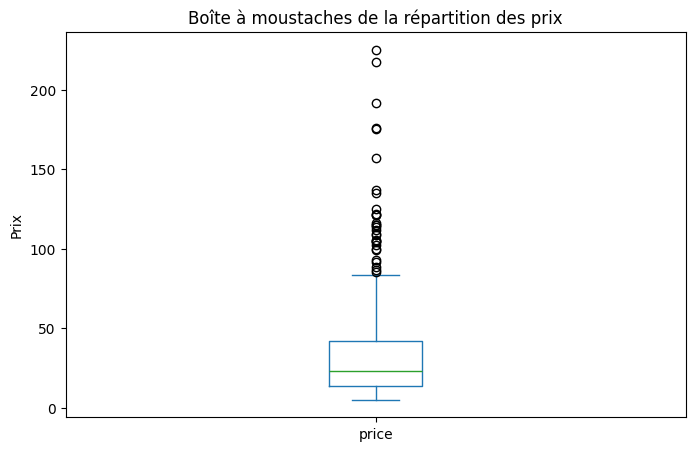

In [362]:
# Création d'une boîte à moustache de la répartition des prix grâce à Pandas
import matplotlib.pyplot as plt
df_final["price"].plot.box(figsize=(8,5))


plt.title("Boîte à moustaches de la répartition des prix")
plt.ylabel("Prix")
plt.show()

In [363]:
# Autre méthode avec plotly express

fig = px.box(
    df_final,
    y="price",
    title="Boîte à moustaches de la répartition des prix"
)

fig.show()

La moitié des prix est comprise entre 14 € et 42 €.
Le prix médian est de 23,45 €.
La distribution est asymétrique à droite : quelques produits sont nettement plus chers que la majorité.
Il existe des valeurs atypiques élevées.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [364]:
#Calcule de la moyenne du prix
prix_moyen = df_final['price'].mean()
print(f"La moyenne des prix est de {round(prix_moyen,2)} €\n")

#Calculer l'écart-type du prix
ecart_type_prix = df_final['price'].std()
print(f"L'écart-type du prix est de {round(ecart_type_prix,2)} \n")

La moyenne des prix est de 32.38 €

L'écart-type du prix est de 27.63 



In [365]:
# Le Z-score mesure l’écart à la moyenne en nombre d’écarts-types
df_z = df_final # Création du dataframe d'analyse du Z-score
df_z["z_score"] = (
    df_z["price"] - prix_moyen
) / ecart_type_prix

df_z[["price", "z_score"]].head()

,price,z_score
0,24.2,-0.295942
1,34.3,0.069577
2,20.8,-0.418988
3,14.1,-0.661461
4,46.0,0.492999


Le Z-score permet d'identifier les valeurs atypiques (outliers)
👉 règle classique :
|Z| > 2 → suspect
|Z| > 3 → atypique fort

Dans le dataframe "df_final" Z-score permet de détecter les produits premium et d'identifier le cœur de gamme (Z proche de 0)

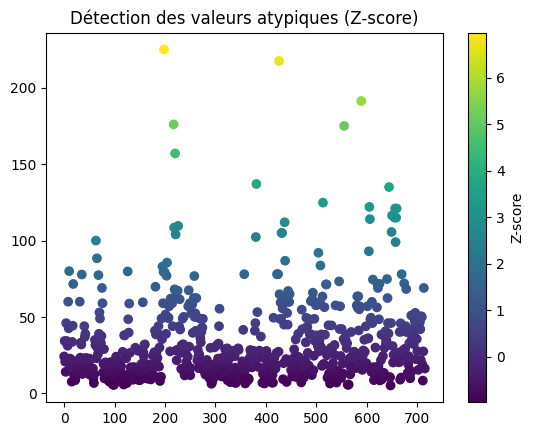

In [366]:
# Visualisation des outliers grace à un graphique en nuage de point :
plt.scatter(df_z.index, df_z["price"], c=df_z["z_score"])
plt.colorbar(label="Z-score")
plt.title("Détection des valeurs atypiques (Z-score)")
plt.show()

In [367]:
# Calcul du seuil de prix dont le z-score est supérieur à 3 :
seuil = prix_moyen + 3 * ecart_type_prix
print(f"le seuil de prix (Z-score > 3) est de {round(seuil,2)} €")

le seuil de prix (Z-score > 3) est de 115.27 €


In [368]:
# Identification des produits haut de gamme :
df_outliers = df_z[df_z["price"] > seuil]
print("Nombre de produits haut de gamme (Z-score > 3) :", len(df_outliers))
df_outliers[["post_title", "price"]].sort_values("price", ascending=False)

Nombre de produits haut de gamme (Z-score > 3) : 13


,post_title,price
198,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0
426,David Duband Charmes-Chambertin Grand Cru 2014,217.5
589,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,191.3
217,Cognac Frapin VIP XO,176.0
555,Camille Giroud Clos de Vougeot 2016,175.0
220,Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age,157.0
381,Domaine Des Croix Corton Charlemagne Grand Cru 2016,137.0
644,Champagne Gosset Célébris Vintage 2007,135.0
513,Domaine Weinbach Gewurztraminer Grand Cru Furstentum SGN 2010 1/2,124.8
605,Wemyss Malts Single Cask Scotch Whisky Choc 'n' Nut Pretzel 2001 Bunnahabhain,122.0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile (IQR) </h3>
</div>

In [369]:
# Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion :
stats = round(df_final["price"].describe(),2)
print(stats)

count    710.00
mean      32.38
std       27.63
min        5.20
25%       14.10
50%       23.45
75%       42.08
max      225.00
Name: price, dtype: float64


Définition du seuil des outliers par la méthode IQR (écart interquartile) :
👉 IQR = Q3−Q1
👉 Seuil haut = Q3+1.5×IQR
👉 Seuil bas = Q1-1.5×IQR

In [370]:
Q1 = df_final["price"].quantile(0.25)
Q3 = round(df_final["price"].quantile(0.75),2)

IQR = round(Q3 - Q1,2)

borne_sup = Q3 + 1.5 * IQR
borne_inf = round(Q1 - 1.5 * IQR,2)

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Seuil inférieur :", borne_inf)
print("Seuil supérieur :", borne_sup)

Q1 : 14.1
Q3 : 42.08
IQR : 27.98
Seuil inférieur : -27.87
Seuil supérieur : 84.05


In [371]:
# Définition du nombre d'articles et proportion du catalogue "outliers"
outliers = df_final[df_final["price"] > borne_sup]

nb_outliers = len(outliers)
nb_total = len(df_final)

proportion = nb_outliers*100 / nb_total

print("Nombre d'outliers :", nb_outliers)
print(f"La proportion des outliers est de {round(proportion,2)} %")

Nombre d'outliers : 31
La proportion des outliers est de 4.36 %


L’analyse par l’intervalle interquartile met en évidence 31 produits atypiques, représentant environ 4,6 % du catalogue. Ces produits présentent des prix supérieurs à 84 €, seuil défini par la méthode IQR.

Ces valeurs ne semblent pas aberrantes mais reflètent plutôt la présence de produits haut de gamme dans le catalogue. La distribution des prix est asymétrique à droite, ce qui est cohérent avec un marché comprenant une majorité de produits standards et une minorité de produits premium.

In [372]:
# Analyse par type de produit
df_final.groupby("product_type")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
Champagne,27.0,71.737037,47.175834,22.5,42.000,59.00,81.250,225.0
Cognac,8.0,97.500000,48.153208,44.0,61.850,86.05,120.625,176.0
Gin,2.0,36.000000,0.000000,36.0,36.000,36.00,36.000,36.0
Huile d'olive,3.0,24.933333,15.291937,13.1,16.300,19.50,30.850,42.2
Vin,656.0,29.278201,23.453241,5.2,13.500,21.85,38.400,217.5
Whisky,14.0,65.557143,26.060129,27.5,51.375,59.00,61.450,122.0


In [373]:
# Visualiser les produits outliers
df_outliers = outliers[["post_title", "price"]].sort_values("price", ascending=False)
df_outliers.head()

,post_title,price
198,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0
426,David Duband Charmes-Chambertin Grand Cru 2014,217.5
589,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,191.3
217,Cognac Frapin VIP XO,176.0
555,Camille Giroud Clos de Vougeot 2016,175.0


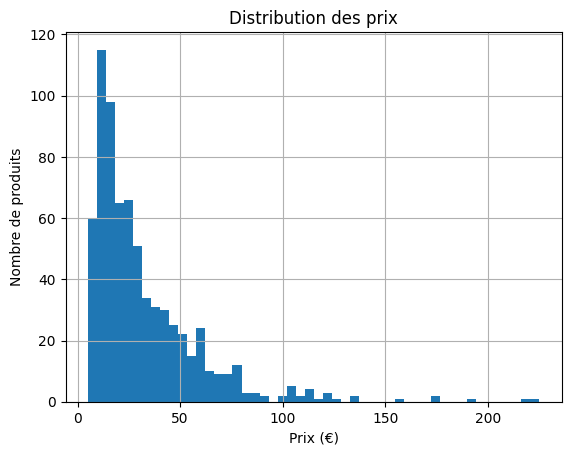

In [374]:
# Analyse distribution
df_final["price"].hist(bins=50)

plt.title("Distribution des prix")
plt.xlabel("Prix (€)")
plt.ylabel("Nombre de produits")

plt.show()

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [375]:
##############################
# Calculer le CA du site web #
##############################

df_ca = df_final
df_ca['ca_par_article'] = df_ca['price'] * df_ca['total_sales']
df_ca[['post_title', 'price', 'total_sales', 'ca_par_article']].head()

,post_title,price,total_sales,ca_par_article
0,Pierre Jean Villa Saint-Joseph Préface 2018,24.2,6,145.2
1,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,34.3,9,308.7
2,Pierre Jean Villa Crozes-Hermitage Accroche Coeur 2018,20.8,0,0.0
3,Pierre Jean Villa IGP Collines Rhodaniennes Gamine 2018,14.1,12,169.2
4,Pierre Jean Villa Côte Rôtie Carmina 2017,46.0,3,138.0


In [376]:
# Calcul du chiffre d'affaire du site web
ca_total = df_ca['ca_par_article'].sum()
ca_format = f"{ca_total:,.2f}".replace(",", " ").replace(".", ",")
print(f"Le chiffre d'affaires total du site est de {ca_format} €")

Le chiffre d'affaires total du site est de 143 204,70 €


In [377]:
###############################
# Palmarès des articles en CA #
###############################

# Tri dans l'ordre décroissant du CA du dataset
df_sorted = df_final.sort_values(by="ca_par_article", ascending=False)
df_sorted.head()

,product_id,id_web,product_type,post_title,total_sales,price,purchase_price,stock_quantity,stock_status,z_score,ca_par_article
198,4352,15940,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,11,225.0,137.81,0,outofstock,6.971006,2475.0
589,5892,14983,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,6,191.3,116.06,98,instock,5.751404,1147.8
199,4353,12587,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,14,79.5,45.91,127,instock,1.705364,1113.0
584,5826,15325,Vin,Agnès Levet Côte Rôtie Améthyste 2017,20,41.2,21.71,34,instock,0.319287,824.0
655,6212,13996,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2015,7,115.0,59.42,16,instock,2.990108,805.0


In [378]:
# Réinitialisation de l'index du dataset :
df_sorted = df_sorted.reset_index(drop=True)
df_sorted.head()

,product_id,id_web,product_type,post_title,total_sales,price,purchase_price,stock_quantity,stock_status,z_score,ca_par_article
0,4352,15940,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,11,225.0,137.81,0,outofstock,6.971006,2475.0
1,5892,14983,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,6,191.3,116.06,98,instock,5.751404,1147.8
2,4353,12587,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,14,79.5,45.91,127,instock,1.705364,1113.0
3,5826,15325,Vin,Agnès Levet Côte Rôtie Améthyste 2017,20,41.2,21.71,34,instock,0.319287,824.0
4,6212,13996,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2015,7,115.0,59.42,16,instock,2.990108,805.0


In [379]:
# Selection et affichage des 20 premiers articles en CA
top20 = df_sorted.head(20).copy()

# Arrondir le chiffre d'affaires pour un affichage plus lisible
top20["ca_par_article"] = top20["ca_par_article"].round().astype(int)

top20[["post_title", "ca_par_article"]]

,post_title,ca_par_article
0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,2475
1,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,1148
2,Champagne Egly-Ouriet Grand Cru Brut Rosé,1113
3,Agnès Levet Côte Rôtie Améthyste 2017,824
4,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2015,805
5,Champagne Agrapart &amp; Fils Minéral Extra Brut Blanc de Blancs Grand Cru 2012,781
6,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2013,735
7,Camille Giroud Clos de Vougeot 2016,700
8,Champagne Gosset Célébris Vintage 2007,675
9,Champagne Agrapart &amp; Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,672


In [380]:
# Création du graphique en barres horizontales
fig = px.bar(
    top20,
    x="ca_par_article",
    y="post_title",
    orientation="h",
    text="ca_par_article",  # afficher les valeurs du CA/barre
    title="Top 20 des articles par chiffre d'affaires"
)

# Amélioration de l'affichage
fig.update_traces(textposition="outside")

fig.update_layout(
    xaxis_title="Chiffre d'affaires (€)",
    yaxis_title="Produits",
    height=800,  # plus d'espace vertical
    width=1200,
    margin=dict(l=300),  # espace pour les noms longs
    yaxis=dict(autorange="reversed", automargin=True),
    template="plotly_white"
)

# Affichage du graphique
fig.show()

In [381]:
#############################
# Calculer le 20 / 80 en CA #
#############################

# Trie du dataset par chiffre d'affaires décroissant et réinitialisation de l'index
df_pareto = df_final.sort_values(by="ca_par_article", ascending=False).reset_index(drop=True).copy()

# Calculer le chiffre d'affaires total
ca_total = df_pareto["ca_par_article"].sum()

In [382]:
# Création d'une colonne contenant la part du CA de chaque article dans le CA total
df_pareto["part_ca"] = df_pareto["ca_par_article"] / ca_total

In [383]:
# Création d'une colonne contenant la somme cumulative de la part de CA
df_pareto["part_ca_cumulee"] = df_pareto["part_ca"].cumsum()

In [384]:
# Identification des articles qui représentent 80 % du CA
articles_80 = df_pareto[df_pareto["part_ca_cumulee"] <= 0.80]

In [385]:
# Calcule du nombre d'articles représentant 80 % du CA
nb_articles_80 = len(articles_80)

In [386]:
# Calcule de la proportion de ces articles dans le catalogue complet
nb_total_articles = len(df_pareto)
proportion_articles_80 = nb_articles_80 / nb_total_articles

In [387]:
# Affichage des résultats :
print("CA total :", ca_format, "€")
print("Nombre d'articles représentant 80 % du CA :", nb_articles_80)
print("Nombre total d'articles dans le catalogue :", nb_total_articles)
print("Proportion dans le catalogue :", round(proportion_articles_80 * 100, 2), "%")

# Affichage d'un aperçu des colonnes créées :
display(df_pareto[["post_title", "ca_par_article", "part_ca", "part_ca_cumulee"]].head(10))

CA total : 143 204,70 €
Nombre d'articles représentant 80 % du CA : 432
Nombre total d'articles dans le catalogue : 711
Proportion dans le catalogue : 60.76 %


,post_title,ca_par_article,part_ca,part_ca_cumulee
0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,2475.0,0.017283,0.017283
1,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,1147.8,0.008015,0.025298
2,Champagne Egly-Ouriet Grand Cru Brut Rosé,1113.0,0.007772,0.033070
3,Agnès Levet Côte Rôtie Améthyste 2017,824.0,0.005754,0.038824
4,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2015,805.0,0.005621,0.044445
5,Champagne Agrapart &amp; Fils Minéral Extra Brut Blanc de Blancs Grand Cru 2012,781.2,0.005455,0.049901
6,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2013,735.0,0.005133,0.055033
7,Camille Giroud Clos de Vougeot 2016,700.0,0.004888,0.059921
8,Champagne Gosset Célébris Vintage 2007,675.0,0.004714,0.064635
9,Champagne Agrapart &amp; Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,672.0,0.004693,0.069327


L’analyse de Pareto montre que le chiffre d’affaires est concentré sur un nombre limité d’articles. En calculant la part de CA de chaque produit puis son cumul, on identifie le nombre d’articles nécessaires pour atteindre 80 % du chiffre d’affaires total. Cela permet de mettre en évidence les produits stratégiques du catalogue : 60% des articles constituent 80% du CA.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [388]:
#####################################
# Palmarès des articles en quantité #
#####################################

# Tri dans l'ordre décroissant de quantités vendues
top20_qty = df_final.sort_values(by='stock_quantity', ascending=False)

# Réinitialisation de l'index
top20_qty = top20_qty.reset_index(drop=True)

# Selection des 20 premiers articles en quantité
top20_qty = top20_qty.head(20).copy()

In [389]:
# Graphique en barre des 20 premiers articles avec plotly express

fig = px.bar(
    top20_qty,
    x="stock_quantity",
    y="post_title",
    orientation="h",
    text="stock_quantity",
    title="Top 20 des articles par quantités vendues"
)

# Amélioration de l'affichage
fig.update_traces(textposition="outside")

fig.update_layout(
    xaxis_title="Quantités vendues",
    yaxis_title="Produits",
    height=800,
    width=1200,
    margin=dict(l=300),
    yaxis=dict(autorange="reversed", automargin=True),
    template="plotly_white"
)

fig.show()

In [390]:
##################################
# Calculer le 20 / 80 en quantité #
##################################

# Trie du dataset par quantité décroissante et réinitialisation de l'index
df_pareto_qty = df_final.sort_values(by='total_sales', ascending=False).reset_index(drop=True).copy()
df_pareto_qty = df_pareto_qty[colonnes_utiles].copy()
df_pareto_qty.head()

,product_id,id_web,product_type,post_title,total_sales,price,purchase_price,stock_quantity,stock_status
0,4867,16148,Vin,Château De La Selve IGP Coteaux de l'Ardèche Maguelonne Rosé 2019,36,9.9,4.86,121,instock
1,4203,15415,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blancs 2018,27,9.9,5.01,74,instock
2,4275,14864,Vin,I Fabbri Chianti Classico Lamole 2017,24,14.9,7.78,62,instock
3,4726,14950,Vin,François Baur Pinot Noir Schlittweg 2017,22,12.7,6.82,0,outofstock
4,4647,16525,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22,28.5,14.14,45,instock


In [391]:
# Créer une colonne de part en quantité
df_pareto_qty["part_qty"] = df_pareto_qty["total_sales"] / df_pareto_qty["total_sales"].sum()

# Créer la somme cumulative de cette part
df_pareto_qty["part_qty_cumulee"] = df_pareto_qty["part_qty"].cumsum()

# Calculer le nombre d'articles représentant 80 % des ventes
nb_articles_80_qty = (df_pareto_qty["part_qty_cumulee"] <= 0.80).sum()

# Calculer la proportion que cela représente dans le catalogue
proportion_catalogue_qty = nb_articles_80_qty / df_pareto_qty["product_id"].nunique()

# Affichage
print(f"Nombre d'articles représentant 80 % des ventes : {nb_articles_80_qty}")
print(f"Proportion du catalogue : {proportion_catalogue_qty:.2%}")


Nombre d'articles représentant 80 % des ventes : 431
Proportion du catalogue : 60.62%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [392]:
# Création du dataframe df_stock
df_stock = df_final
df_stock.head()

,product_id,id_web,product_type,post_title,total_sales,price,purchase_price,stock_quantity,stock_status,z_score,ca_par_article
0,3847,15298,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,6,24.2,12.88,16,instock,-0.295942,145.2
1,3849,15296,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,9,34.3,17.54,10,instock,0.069577,308.7
2,3850,15300,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Coeur 2018,0,20.8,10.64,0,outofstock,-0.418988,0.0
3,4032,19814,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Gamine 2018,12,14.1,6.92,26,instock,-0.661461,169.2
4,4039,19815,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,3,46.0,23.77,3,instock,0.492999,138.0


In [393]:
######################################
# Calculer le nombre de mois de stock #
######################################

# Création de la colonne "rotation_stock" c-à-dire le stock disponible / quantités vendues
df_stock['rotation_stock'] = np.where(
    df_stock['total_sales'] > 0,
    (df_stock['stock_quantity'] / df_stock['total_sales']),
    np.nan
).round(1)

# Tri dans l'ordre décroissant du nombre de mois de stock
df_stock_sorted = df_stock.sort_values(by="rotation_stock", ascending=False).reset_index(drop=True)

# Sélection du flop 20 des produits ayant le plus de mois de stock
flop20_stock = df_stock_sorted.head(20).copy()

# Arrondir pour un affichage plus lisible
flop20_stock["rotation_stock"] = flop20_stock["rotation_stock"].round(1)

# Afficher les 20 produits concernés
display(flop20_stock[["post_title", "stock_quantity", "total_sales", "rotation_stock"]])

,post_title,stock_quantity,total_sales,rotation_stock
0,Champagne Gosset Grand Millésime 2006,125,4,31.2
1,Champagne Gosset Célébris Vintage 2007,138,5,27.6
2,Champagne Egly-Ouriet Premier Cru Les Vignes de Vrigny,81,3,27.0
3,Champagne Egly-Ouriet Grand Cru Brut Tradition,125,5,25.0
4,Champagne Mailly Grand Cru Brut Rosé,71,3,23.7
5,Champagne Larmandier-Bernier Latitude,115,5,23.0
6,Champagne Gosset Grand Rosé,91,4,22.8
7,Champagne Agrapart &amp; Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,136,6,22.7
8,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,145,7,20.7
9,Champagne Mailly Grand Cru Intemporelle 2010,123,6,20.5


In [394]:
# Graphique en barre des 20 premiers articles avec des rotation de stock important

fig = px.bar(
    flop20_stock,
    x="rotation_stock",
    y="post_title",
    orientation="h",
    text="rotation_stock",
    title="Flop 20 des produits avec le plus de mois de stock"
)

# Position du texte
fig.update_traces(textposition="outside")

# Mise en forme pour lisibilité
fig.update_layout(
    xaxis_title="Nombre de mois de stock",
    yaxis_title="Produits",
    height=800, # espace vertical
    width=1200,
    margin=dict(l=320),          # espace pour noms longs
    yaxis=dict(autorange="reversed", automargin=True),
    template="plotly_white"
)

fig.show()

In [395]:
####################################
# Valorisation des stocks en euros #
####################################

print("=== VALEUR DU STOCK ===")

df_stock['stock_value'] = df_stock['stock_quantity'] * df_stock['purchase_price']
stock_total = df_stock['stock_value'].sum()
stock_total = round(stock_total)
print(f"Valeur totale du stock (prix d'achat) : {stock_total} €")
print(f"Produits en rupture de stock           : {(df_stock['stock_status'] == 'outofstock').sum()}")
print(f"Produits en stock                      : {(df_stock['stock_status'] == 'instock').sum()}")
print()

=== VALEUR DU STOCK ===
Valeur totale du stock (prix d'achat) : 269241 €
Produits en rupture de stock           : 45
Produits en stock                      : 666



In [396]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

print(f"La quantité totale de produits en stock est de {df_stock['stock_quantity'].sum()}.")


La quantité totale de produits en stock est de 16678.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [397]:
############################
# Analyse du taux de marge #
############################

# Création du dataframe taux de marge
df_marge = df_stock.copy()

# Création de la colonne prix HT
df_marge["price_ht"] = round(df_marge['price'] / 1.2,2)

# Création de la colonne Taux de marge
df_marge["taux_marge"] = np.where(
    df_marge["purchase_price"] > 0,
    (df_marge["price_ht"] - df_marge["purchase_price"]) / df_marge["purchase_price"],
    np.nan
)

# Afficher le prix minimum de la colonne "taux_marge"
taux_marge_min = df_marge["taux_marge"].min()

# Afficher le prix maximum de la colonne "taux_marge"
taux_marge_max = df_marge["taux_marge"].max()

print("Taux de marge minimum :", round(taux_marge_min * 100, 2), "%")
print("Taux de marge maximum :", round(taux_marge_max * 100, 2), "%")

Taux de marge minimum : 29.54 %
Taux de marge maximum : 91.41 %


In [398]:
# Afficher les lignes avec un taux de marge inférieur à 0
df_marge[df_marge["taux_marge"] < 0][
    ["post_title", "price_ht", "purchase_price", "taux_marge"]
]

,post_title,price_ht,purchase_price,taux_marge


In [399]:
df_marge.head()

,product_id,id_web,product_type,post_title,total_sales,price,purchase_price,stock_quantity,stock_status,z_score,ca_par_article,rotation_stock,stock_value,price_ht,taux_marge
0,3847,15298,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,6,24.2,12.88,16,instock,-0.295942,145.2,2.7,206.08,20.17,0.565994
1,3849,15296,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,9,34.3,17.54,10,instock,0.069577,308.7,1.1,175.40,28.58,0.629418
2,3850,15300,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Coeur 2018,0,20.8,10.64,0,outofstock,-0.418988,0.0,NaN,0.00,17.33,0.628759
3,4032,19814,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Gamine 2018,12,14.1,6.92,26,instock,-0.661461,169.2,2.2,179.92,11.75,0.697977
4,4039,19815,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,3,46.0,23.77,3,instock,0.492999,138.0,1.0,71.31,38.33,0.612537


In [400]:
# Création d'un dataframe avec les taux positifs en filtrant uniquement les marges positives
df_marge_positive = df_marge[df_marge["taux_marge"] > 0]

# Afficher le prix minimum de la colonne "taux_marge"
taux_min = df_marge_positive["taux_marge"].min()
print("Taux de marge minimum :", round(taux_min * 100,2))

# Afficher le prix maximum de la colonne "taux_marge"
taux_max = df_marge_positive["taux_marge"].max()
print("Taux de marge maximum :", round(taux_max *100,2))


Taux de marge minimum : 29.54
Taux de marge maximum : 91.41


In [401]:
# Création d'un dataframe avec le taux de marge moyen par type de produit
df_marge_type = df_marge.groupby("product_type")["taux_marge"].mean().reset_index()

# Conversion en pourcentage
df_marge_type["taux_marge_pct"] = (df_marge_type["taux_marge"] * 100).round(1)

# Tri décroissant
df_marge_type = df_marge_type.sort_values(by="taux_marge_pct", ascending=False)

# Création du graphique
fig = px.bar(
    df_marge_type,
    x="taux_marge_pct",
    y="product_type",
    orientation="h",
    text="taux_marge_pct",
    title="Taux de marge moyen (%) par type de produit",
    color="taux_marge_pct",  # couleur selon valeur
    color_continuous_scale="Blues"
)

# Amélioration des labels
fig.update_traces(
    texttemplate="%{text}%",
    textposition="outside"
)

# Mise en forme globale
fig.update_layout(
    xaxis_title="Taux de marge moyen (%)",
    yaxis_title="Type de produit",
    yaxis=dict(autorange="reversed", automargin=True),
    height=500,
    width=1200,
    template="plotly_white",
    coloraxis_colorbar=dict(title="Marge (%)")
)

fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

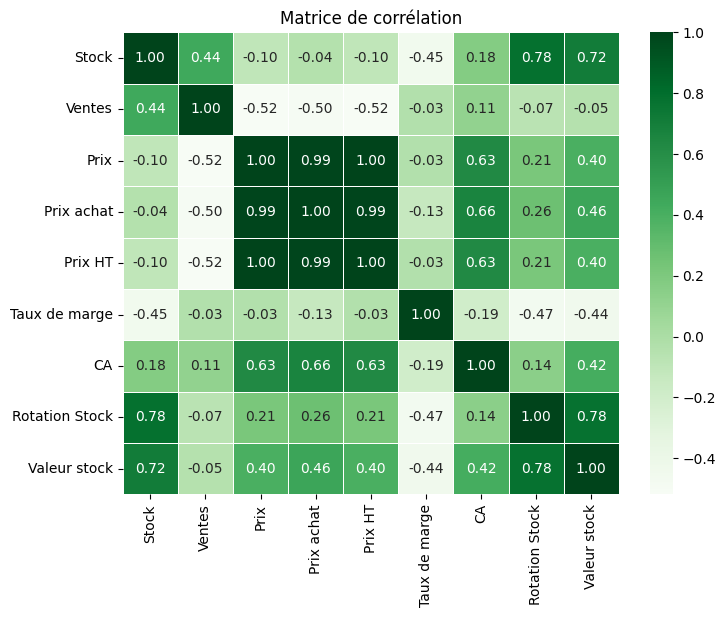

In [402]:
############################
# Analyse des corrélations #
############################

# Importation de Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Sélection des colonnes numériques pertinentes pour la corrélation
correlation_columns = [
    'stock_quantity',
    'total_sales',
    'price',
    'purchase_price',
    'price_ht',
    'taux_marge',
    'ca_par_article',
    'rotation_stock',
    'stock_value'
]

# Calcul de la matrice de corrélation
corr_matrix = df_marge[correlation_columns].corr()

# Création d'une heatmap de corrélation avec les variables de prix, de stock et de ventes
plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix,
    annot=True,
    cmap="Greens",
    fmt=".2f",
    linewidths=0.5,
    xticklabels=['Stock','Ventes','Prix','Prix achat','Prix HT','Taux de marge','CA','Rotation Stock','Valeur stock'],
    yticklabels=['Stock','Ventes','Prix','Prix achat','Prix HT','Taux de marge','CA','Rotation Stock','Valeur stock']
)

plt.title("Matrice de corrélation")
plt.show()

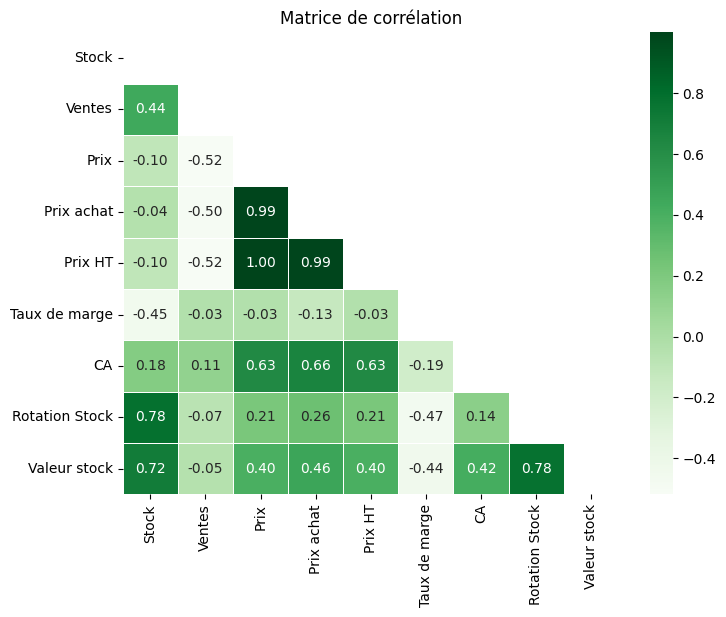

In [403]:
# Création du mask (triangle supérieur) pour éviter les doublons visuels car la matrice est symétrique

mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # np.ones_like → crée une matrice de True,
                                                      # np.triu → garde le triangle supérieur
                                                      # mask → cache cette partie dans la heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix,
    annot=True,
    mask = mask,
    cmap="Greens",
    fmt=".2f",
    linewidths=0.5,
    xticklabels=['Stock','Ventes','Prix','Prix achat','Prix HT','Taux de marge','CA','Rotation Stock','Valeur stock'],
    yticklabels=['Stock','Ventes','Prix','Prix achat','Prix HT','Taux de marge','CA','Rotation Stock','Valeur stock']
)

plt.title("Matrice de corrélation")
plt.show()

Stock vs Ventes (+0.44) ➡️ logique d’approvisionnement adaptée à la demande
Prix HT vs Ventes (-0.52) ➡️ Plus le prix augmente → moins les ventes sont élevées
Prix vs Prix d’achat (+0.98) ➡️ Le prix de vente est directement lié au prix d’achat
Prix d’achat vs Ventes (-0.50) ➡️ Les produits coûteux se vendent moins

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [404]:
# Export du dataset d'analyse sur un fichier Excel
df_analyse_final = df_marge.copy()
df_final.to_excel("df_final.xlsx", index=False)

In [405]:
df_analyse_final.head()

,product_id,id_web,product_type,post_title,total_sales,price,purchase_price,stock_quantity,stock_status,z_score,ca_par_article,rotation_stock,stock_value,price_ht,taux_marge
0,3847,15298,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,6,24.2,12.88,16,instock,-0.295942,145.2,2.7,206.08,20.17,0.565994
1,3849,15296,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,9,34.3,17.54,10,instock,0.069577,308.7,1.1,175.40,28.58,0.629418
2,3850,15300,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Coeur 2018,0,20.8,10.64,0,outofstock,-0.418988,0.0,NaN,0.00,17.33,0.628759
3,4032,19814,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Gamine 2018,12,14.1,6.92,26,instock,-0.661461,169.2,2.2,179.92,11.75,0.697977
4,4039,19815,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,3,46.0,23.77,3,instock,0.492999,138.0,1.0,71.31,38.33,0.612537


In [406]:
# Synthese des chiffres clés

ca_total = df_final['ca_par_article'].sum()
quantites_total = df_final['total_sales'].sum()
stock_total = df_final['stock_quantity'].sum()
valeur_stock = (df_final['stock_quantity'] * df_final['purchase_price']).sum()
print(f"Chiffre d'affaires total : {round(ca_total, 2)} €")
print(f"Quantités vendues : {int(quantites_total)}")
print(f"Stock total ERP : {int(stock_total)} unités")
print(f"Valeur de stock au prix d'achat : {round(valeur_stock, 2)} €")

Chiffre d'affaires total : 143204.7 €
Quantités vendues : 5726
Stock total ERP : 16678 unités
Valeur de stock au prix d'achat : 269240.57 €


<div style="background-color: RGB(51,165,182);">
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 -Synthèse des erreurs et recommandations </h2>
</div>

In [407]:
# Tableau de synthèse des erreurs
erreurs = [
    {"N°": "E1", "Source": "ERP", "Type": "Anomalie", "Description": "stock_status incohérent vs stock_quantity (2 lignes)", "Correction": "Recalcul de stock_status depuis stock_quantity"},
    {"N°": "E2", "Source": "ERP", "Type": "Erreur de saisie", "Description": "3 prix négatifs (-20, -8, -9.1 €)", "Correction": "Valeur absolue appliquée"},
    {"N°": "E3", "Source": "ERP", "Type": "Erreur de saisie", "Description": "2 stock_quantity négatifs (-10, -1)", "Correction": "Valeurs ramenées à 0"},
    {"N°": "E4", "Source": "ERP", "Type": "Erreur de calcul", "Description": "1 produit vendu sous le coût d'achat", "Correction": "Vérification manuelle et exclusion des valeurs incohérentes(Nan)"},
    {"N°": "E5", "Source": "WEB", "Type": "Données manquantes", "Description": "85 produits sans SKU", "Correction": "Suppression des lignes correspondantes"},
    {"N°": "E6", "Source": "WEB", "Type": "Erreur de saisie", "Description": "2 produits avec total_sales négatif (-56, -17)", "Correction": "Lignes supprimées avec les 85 lignes sans sku "},
    {"N°": "E7", "Source": "WEB", "Type": "Anomalie", "Description": "Identification de 2 valeurs SKU", "Correction": "Valeurs isolées puis exclues du dataset"},
    {"N°": "E8", "Source": "LIAISON", "Type": "Anomalie", "Description": "Identification de 3 valeurs id_web non numériques", "Correction": "Valeurs remplacé par NaN "},
    {"N°": "E9", "Source": "LIAISON", "Type": "Données manquantes", "Description": "91 product_id ERP sans id_web ", "Correction": "Suppression des lignes sans id_web "},
    {"N°": "E10", "Source": "JOINTURE", "Type": "Anomalie", "Description": " Identification de 5 produits normalement vendus sur le web non mappées dans la table de liaison", "Correction": "A traiter"},
    {"N°": "E11", "Source": "JOINTURE", "Type": "Données manquantes", "Description": "Id sans correspondance", "Correction": "Filtrage des NaN"},

]

df_erreurs = pd.DataFrame(erreurs)
df_erreurs

,N°,Source,Type,Description,Correction
0,E1,ERP,Anomalie,stock_status incohérent vs stock_quantity (2 lignes),Recalcul de stock_status depuis stock_quantity
1,E2,ERP,Erreur de saisie,"3 prix négatifs (-20, -8, -9.1 €)",Valeur absolue appliquée
2,E3,ERP,Erreur de saisie,"2 stock_quantity négatifs (-10, -1)",Valeurs ramenées à 0
3,E4,ERP,Erreur de calcul,1 produit vendu sous le coût d'achat,Vérification manuelle et exclusion des valeurs incohérentes(Nan)
4,E5,WEB,Données manquantes,85 produits sans SKU,Suppression des lignes correspondantes
5,E6,WEB,Erreur de saisie,"2 produits avec total_sales négatif (-56, -17)",Lignes supprimées avec les 85 lignes sans sku
6,E7,WEB,Anomalie,Identification de 2 valeurs SKU,Valeurs isolées puis exclues du dataset
7,E8,LIAISON,Anomalie,Identification de 3 valeurs id_web non numériques,Valeurs remplacé par NaN
8,E9,LIAISON,Données manquantes,91 product_id ERP sans id_web,Suppression des lignes sans id_web
9,E10,JOINTURE,Anomalie,Identification de 5 produits normalement vendus sur le web non mappées dans la table de liaison,A traiter


In [408]:
# Recommandations
recommandations = {
    "Court terme": [
        "Corriger les produits vendus sous le coût d'achat dans l'ERP",
        "Publier ou désactiver les 91 produits ERP sans équivalent web",
    ],
    "Moyen terme": [
        "Ajouter des contraintes de validation dans l'ERP (prix > 0, stock >= 0)",
        "Automatiser la synchronisation stock_status ↔ stock_quantity",
        "Mettre en place un processus de réconciliation mensuel WEB / ERP",
    ],
    "Long terme": [
        "Implémenter un outil de Data Visualisation connecté en temps réel",
        "Créer des alertes automatiques sur les seuils critiques (rupture, sur-stock, marge <0)",
        "Unifier les référentiels produits entre WEB et l'ERP",
    ]
}

for horizon, items in recommandations.items():
    print(f"\n{'='*50}")
    print(f"  {horizon.upper()}")
    print(f"{'='*50}")
    for item in items:
        print(f"  • {item}")


  COURT TERME
  • Corriger les produits vendus sous le coût d'achat dans l'ERP
  • Publier ou désactiver les 91 produits ERP sans équivalent web

  MOYEN TERME
  • Ajouter des contraintes de validation dans l'ERP (prix > 0, stock >= 0)
  • Automatiser la synchronisation stock_status ↔ stock_quantity
  • Mettre en place un processus de réconciliation mensuel WEB / ERP

  LONG TERME
  • Implémenter un outil de Data Visualisation connecté en temps réel
  • Créer des alertes automatiques sur les seuils critiques (rupture, sur-stock, marge <0)
  • Unifier les référentiels produits entre WEB et l'ERP


In [409]:
# Copie de travail
df_viz = df_final.copy()

# Sécuriser les colonnes utiles
df_viz = df_viz[["post_title", "total_sales", "price"]].copy()

# Supprimer les lignes avec valeurs manquantes
df_viz = df_viz.dropna(subset=["post_title", "total_sales", "price"]).copy()

# Typage
df_viz["total_sales"] = df_viz["total_sales"].astype(int)
df_viz["price"] = df_viz["price"].astype(float)

# Calcul du CA par article
df_viz["ca_par_article"] = df_viz["price"] * df_viz["total_sales"]

df_viz.head()

,post_title,total_sales,price,ca_par_article
0,Pierre Jean Villa Saint-Joseph Préface 2018,6,24.2,145.2
1,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,9,34.3,308.7
2,Pierre Jean Villa Crozes-Hermitage Accroche Coeur 2018,0,20.8,0.0
3,Pierre Jean Villa IGP Collines Rhodaniennes Gamine 2018,12,14.1,169.2
4,Pierre Jean Villa Côte Rôtie Carmina 2017,3,46.0,138.0


In [410]:
# Base pour la matrice
df_matrix = df_viz.copy()

# Seuils = médianes
x_median = df_matrix["total_sales"].median()
y_median = df_matrix["ca_par_article"].median()

print(f"Médiane volume : {x_median}")
print(f"Médiane CA : {y_median:.2f}")

Médiane volume : 8.0
Médiane CA : 168.00


In [411]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Copie de travail
df_viz = df_final.copy()

# Colonnes utiles
df_viz = df_viz[["post_title", "total_sales", "price"]].dropna().copy()

# Typage
df_viz["total_sales"] = df_viz["total_sales"].astype(int)
df_viz["price"] = df_viz["price"].astype(float)

# Calcul du CA
df_viz["ca_par_article"] = df_viz["price"] * df_viz["total_sales"]

In [412]:
df_matrix = df_viz.copy()

# Seuils : médianes
x_median = df_matrix["total_sales"].median()
y_median = df_matrix["ca_par_article"].median()

def segment_produit(row):
    if row["total_sales"] >= x_median and row["ca_par_article"] >= y_median:
        return "Stars"
    elif row["total_sales"] < x_median and row["ca_par_article"] >= y_median:
        return "Premium"
    elif row["total_sales"] >= x_median and row["ca_par_article"] < y_median:
        return "Volume"
    else:
        return "Faibles"

df_matrix["segment"] = df_matrix.apply(segment_produit, axis=1)

df_matrix["label"] = np.where(
    df_matrix["ca_par_article"] >= df_matrix["ca_par_article"].quantile(0.97),
    df_matrix["post_title"],
    ""
)

In [413]:
df_matrix.head()

,post_title,total_sales,price,ca_par_article,segment,label
0,Pierre Jean Villa Saint-Joseph Préface 2018,6,24.2,145.2,Faibles,
1,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,9,34.3,308.7,Stars,
2,Pierre Jean Villa Crozes-Hermitage Accroche Coeur 2018,0,20.8,0.0,Faibles,
3,Pierre Jean Villa IGP Collines Rhodaniennes Gamine 2018,12,14.1,169.2,Stars,
4,Pierre Jean Villa Côte Rôtie Carmina 2017,3,46.0,138.0,Faibles,


In [414]:
fig = px.scatter(
    df_matrix,
    x="total_sales",
    y="ca_par_article",
    color="segment",
    hover_data=["post_title", "price"],
    title="Matrice CA vs volume"
)

# Lignes de séparation
fig.add_vline(x=x_median, line_dash="dash")
fig.add_hline(y=y_median, line_dash="dash")

# Noms des quadrants
x_max = df_matrix["total_sales"].max()
y_max = df_matrix["ca_par_article"].max()


fig.update_layout(
    xaxis_title="Quantités vendues",
    yaxis_title="CA par article (€)",
    template="plotly_white"
)

fig.show()